# Smart Cargo E-Bike, Part 3 — Physics-Based Batteries: from Electrochemistry to a Real-Time ECM

**Reading time ~30 min · runtime ~2 min on CPU (PyBaMM DFN solves in ~1 s).**

In [Part 1](ebike_smart_cargo_tutorial.ipynb) the e-bike carried a **2-RC
equivalent-circuit** battery: three ODEs (`SOC`, two RC overpotentials) and an
open-circuit-voltage curve. It is fast, it closed the energy audit, and it is
the right model to put *inside* a real-time vehicle simulation. But its
parameters (`R0`, `R1`, `C1`, …) are empirical knobs — where do their *values*
come from, and when does a lumped circuit stop being trustworthy?

This notebook answers that by climbing the **battery-modelling hierarchy** with
[PyBaMM](https://pybamm.org): a first-principles **Doyle–Fuller–Newman (DFN)**
electrochemical cell as the physical truth, a **Single-Particle model (SPMe)**
as a physics-based reduced model, and the **2-RC ECM** calibrated *from* the
DFN. We will see the lithium concentration fields inside the electrodes, watch
the cell age, and end knowing exactly when each fidelity level is the right
tool.

> **Prerequisites.** Part 1 (the calibrated e-bike model and its ECM battery).
> Requires `pybamm` (`pip install pybamm`). We reuse helpers from the companion
> script `ebike_pybamm_battery.py`.

## 1. The modelling question: what is a battery model *for*?

A cell is a device that trades chemical energy for electrical work by shuttling
lithium between two porous electrodes through an electrolyte. Which of that
physics you resolve depends on the question:

| Question | Model you need |
|---|---|
| Range / energy over a drive cycle, BMS state estimation, real-time control | **ECM** (0-D circuit) — µs/step, empirical |
| Terminal voltage under a *hard* transient (fast charge, cold start, high C-rate) | **SPMe** or **DFN** — resolves transport limits |
| Aging, lithium plating, safety margins, cell/pack *design* | **DFN** — resolves the internal fields that drive degradation |

The key relationship, which this notebook makes concrete, is that **the
high-fidelity model is how you earn the right to use the cheap one**: you fit
(or reduce) the DFN to get ECM parameters you can defend, then run the ECM in
the vehicle model. This is the same "high-fidelity → ROM → system model"
pattern as the CFD (Part 5) and multibody (Part 4) couplings — here the ladder
just happens to be *within* one physical domain.

## 2. The governing equations, briefly (and why each matters)

**Symbols** — $c_s(r,x,t)$ solid Li concentration [mol m⁻³] (radius $r$ inside a
particle at through-cell position $x$); $c_e(x,t)$ electrolyte concentration;
$\phi_s,\phi_e$ solid/electrolyte potentials [V]; $j$ interfacial current
density [A m⁻²]; $D_s,D_e$ diffusivities [m² s⁻¹]; $i_0$ exchange current;
$\eta$ overpotential [V]; $F$ Faraday's constant.

**(1) Solid diffusion** — lithium diffuses in/out of spherical particles (Fick):
$$ \frac{\partial c_s}{\partial t} = \frac{1}{r^2}\frac{\partial}{\partial r}\!\left(D_s\, r^2 \frac{\partial c_s}{\partial r}\right). \tag{1}$$
The particle *surface* concentration sets the local voltage; when you pull
current faster than $D_s$ can replenish the surface, voltage sags even though
the particle core is still full — that is a *transport* limit an ECM only mimics
through its RC time constants.

**(2) Butler–Volmer kinetics** — the current across the electrode/electrolyte
interface depends *exponentially* on overpotential:
$$ j = i_0\left[\exp\!\Big(\tfrac{\alpha_a F}{RT}\eta\Big) - \exp\!\Big(-\tfrac{\alpha_c F}{RT}\eta\Big)\right]. \tag{2}$$
Dimensional check: $[\eta]=$ V and $F/RT \approx 39\ \mathrm{V^{-1}}$ at 298 K, so
a ~25 mV overpotential already doubles the forward rate — kinetics are stiff and
temperature-sensitive.

**(3) Electrolyte transport + charge conservation** close the system across the
cell thickness. The **DFN** (a.k.a. P2D — pseudo-2-D) solves (1)–(3)
*everywhere*: a radial dimension inside every particle **and** the through-cell
dimension. The **SPMe** collapses each electrode to one representative particle
plus an electrolyte correction — cheap, accurate at low–moderate C-rate. The
**ECM** throws away all spatial structure and fits the terminal response with a
resistor + RC branches.

## 3. Setup

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
import pybamm

sys.path.append(os.path.abspath("."))
from ebike_pybamm_battery import (
    run_pybamm, ocv, ecm_voltage, calibrate_ecm, ebike_current, rmse_mV, T_END,
)

np.random.seed(0)
print("pybamm", pybamm.__version__)

pybamm 26.7.1.0


## 4. An e-bike-representative load, solved three ways

We drive one representative cell (Chen 2020, a 5 Ah 21700 NMC/graphite cell —
our 13S3P pack is 13 of these in series, 3 in parallel, so a cell sees roughly
`pack_current / 3`) with a cruise-plus-hill-plus-regen current profile, and
solve it with the DFN (truth), the SPMe (physics ROM), and the calibrated ECM.

  DFN   : solved in  0.84 s   V 4.104->3.839 V   T 25.00->30.18 C
  SPMe  : solved in  0.15 s   V 4.104->3.834 V   T 25.00->30.30 C


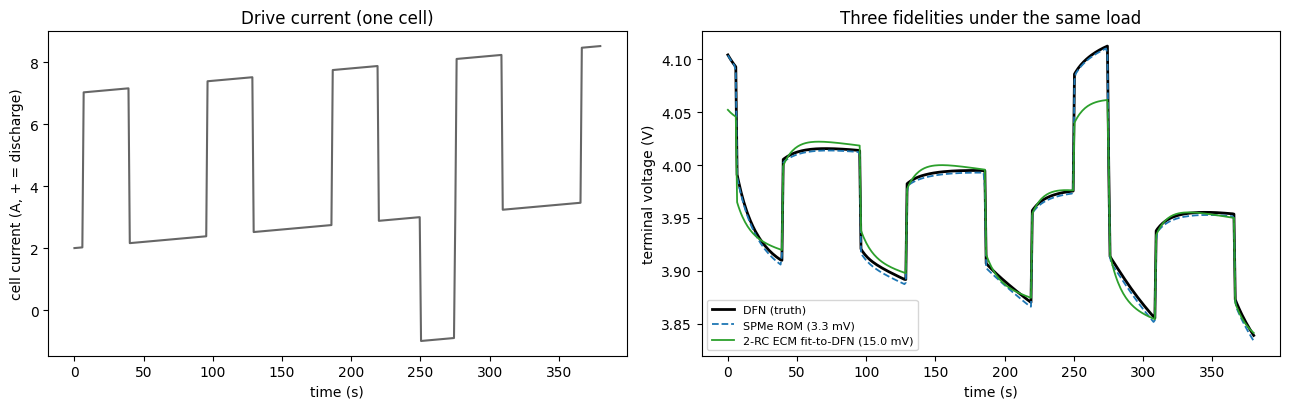

In [2]:
tg = np.linspace(0.0, T_END, 400)
t_dfn, V_dfn, T_dfn, wall_dfn = run_pybamm(pybamm.lithium_ion.DFN, "DFN")
t_spm, V_spm, T_spm, wall_spm = run_pybamm(pybamm.lithium_ion.SPMe, "SPMe")

from scipy.interpolate import interp1d
Vd = interp1d(t_dfn, V_dfn, fill_value="extrapolate")(tg)
Vs = interp1d(t_spm, V_spm, fill_value="extrapolate")(tg)
p_cal = calibrate_ecm(tg, Vd, ebike_current)
V_ecm = ecm_voltage(p_cal, tg, ebike_current)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(tg, ebike_current(tg), color="0.4"); ax[0].set(xlabel="time (s)", ylabel="cell current (A, + = discharge)", title="Drive current (one cell)")
ax[1].plot(tg, Vd, "k", lw=2, label=f"DFN (truth)")
ax[1].plot(tg, Vs, "--", color="tab:blue", lw=1.3, label=f"SPMe ROM ({rmse_mV(Vs,Vd):.1f} mV)")
ax[1].plot(tg, V_ecm, color="tab:green", lw=1.3, label=f"2-RC ECM fit-to-DFN ({rmse_mV(V_ecm,Vd):.1f} mV)")
ax[1].set(xlabel="time (s)", ylabel="terminal voltage (V)", title="Three fidelities under the same load"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

*Figure 1: (left) the single-cell drive current; (right) terminal voltage from
the DFN truth, the SPMe physics-ROM, and the 2-RC ECM calibrated to the DFN. The
SPMe tracks the DFN to a few mV at a fraction of the cost; the calibrated ECM —
the model Part 1 actually uses — reproduces it to ~15 mV. The ECM is not a
guess: its parameters were **fit to the DFN**.*

## 5. Look inside: the fields an ECM cannot see

The whole point of the DFN is the *internal state*. Here are two fields the
lumped ECM has no representation of at all: the **electrolyte concentration
across the cell thickness** and the **lithium concentration inside a negative
particle** (radius × time). Gradients here are what limit fast charge and seed
degradation.

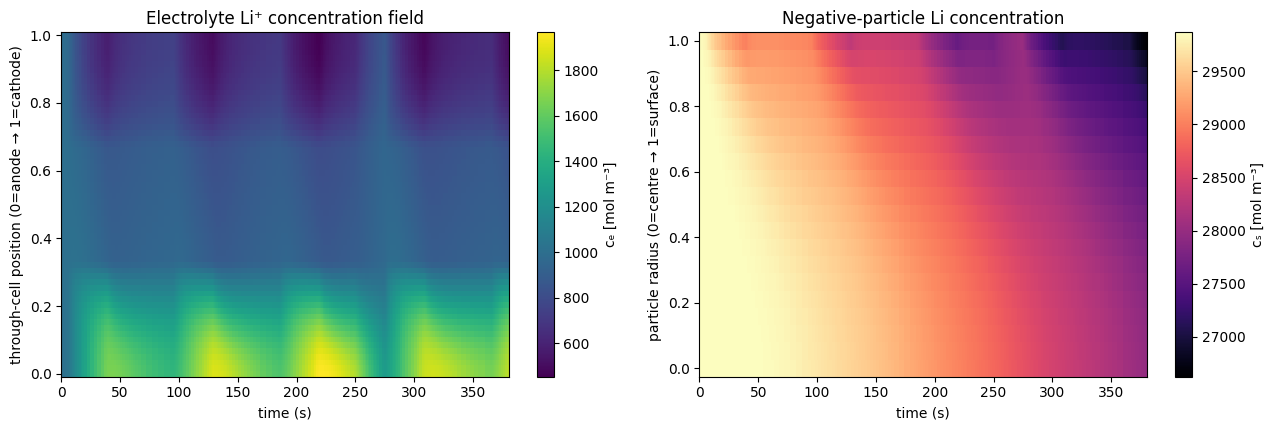

In [3]:
_p = pybamm.ParameterValues("Chen2020")
_p["Current function [A]"] = pybamm.Interpolant(tg, ebike_current(tg), pybamm.t)
sol = pybamm.Simulation(pybamm.lithium_ion.DFN(options={"thermal": "lumped"}),
                        parameter_values=_p).solve([0, T_END])

ce = sol["Electrolyte concentration [mol.m-3]"].entries          # (x, t)
cs = sol["X-averaged negative particle concentration [mol.m-3]"].entries  # (r, t)
tt = sol["Time [s]"].entries

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
im0 = ax[0].pcolormesh(tt, np.linspace(0, 1, ce.shape[0]), ce, shading="auto", cmap="viridis")
fig.colorbar(im0, ax=ax[0], label="cₑ [mol m⁻³]")
ax[0].set(xlabel="time (s)", ylabel="through-cell position (0=anode → 1=cathode)", title="Electrolyte Li⁺ concentration field")
im1 = ax[1].pcolormesh(tt, np.linspace(0, 1, cs.shape[0]), cs, shading="auto", cmap="magma")
fig.colorbar(im1, ax=ax[1], label="cₛ [mol m⁻³]")
ax[1].set(xlabel="time (s)", ylabel="particle radius (0=centre → 1=surface)", title="Negative-particle Li concentration")
fig.tight_layout(); plt.show()

*Figure 2: the DFN's internal fields. Left — electrolyte concentration develops
a **gradient across the cell** whenever current flows (depletion at one
electrode, accumulation at the other); it relaxes during the regen dip. Right —
lithium fills the negative particle from the **surface inward** during charge
and empties surface-first during discharge, so the surface can be depleted while
the core is still full. These gradients are exactly the physics the ECM's RC
branches only *approximate* with a lumped time constant — and they are what a
BMS gets wrong at high C-rate if it trusts an ECM outside its fitted range.*

## 6. When do you actually need the DFN?

| Regime | ECM ok? | Why |
|---|---|---|
| Cruise / gentle drive cycle (our e-bike) | ✅ | Low C-rate, small gradients — RC branches capture the response |
| Fast charge, high-power pulses | ⚠️/❌ | Surface depletion & electrolyte gradients dominate; ECM extrapolates badly |
| Cold temperature | ❌ | Kinetics (2) and $D_s$ drop sharply; strongly nonlinear |
| Aging / lifetime prediction | ❌ | Degradation is driven by *internal* potentials/concentrations |
| Cell or pack *design* | ❌ | You are choosing the geometry/chemistry the ECM would only fit *after the fact* |

The e-bike sits firmly in the green row — which is *why* Part 1's ECM was a
defensible choice. This notebook is how we'd defend it, and how we'd know to
switch if the duty cycle got aggressive.

## 7. Aging: why lifetime needs physics

Capacity fade comes from side reactions — chiefly **SEI (solid-electrolyte
interphase) growth** consuming cyclable lithium, plus plating and particle
cracking. These depend on the *internal* overpotentials, so an ECM can only
*replay* a measured fade curve, never *predict* one from a new duty cycle. We
run the DFN with an SEI submodel over a handful of 1C cycles and watch capacity
fall.

aging: 8 cycles in 0.2s; capacity 5.153 -> 5.152 Ah (0.02% fade)


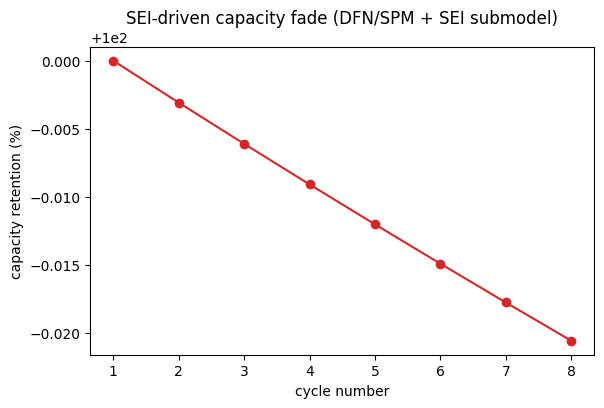

In [4]:
try:
    aging_model = pybamm.lithium_ion.SPM({"SEI": "solvent-diffusion limited"})
    exp = pybamm.Experiment([("Discharge at 1C until 3.0 V", "Charge at 1C until 4.1 V", "Hold at 4.1 V until 50 mA")] * 8)
    t0 = time.time()
    sim_age = pybamm.Simulation(aging_model, experiment=exp, parameter_values=pybamm.ParameterValues("Chen2020"))
    sol_age = sim_age.solve()
    cyc = sol_age.summary_variables["Cycle number"]
    cap = sol_age.summary_variables["Capacity [A.h]"]
    print(f"aging: {len(cyc)} cycles in {time.time()-t0:.1f}s; capacity {cap[0]:.3f} -> {cap[-1]:.3f} Ah "
          f"({(1-cap[-1]/cap[0])*100:.2f}% fade)")
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(cyc, cap / cap[0] * 100, "o-", color="tab:red")
    ax.set(xlabel="cycle number", ylabel="capacity retention (%)", title="SEI-driven capacity fade (DFN/SPM + SEI submodel)")
    plt.show()
    AGING_OK = True
except Exception as e:
    print("aging demo skipped:", type(e).__name__, str(e)[:80]); AGING_OK = False

*Figure 3: capacity retention vs cycle from an SEI-growth submodel. The fade is
**emergent** from the internal chemistry, not fit to a curve — change the C-rate
or temperature and the slope changes physically. This is the headline reason
aging studies use electrochemical models.*

## 8. Temperature: performance is not isothermal

Diffusion and kinetics are strongly Arrhenius. The same current at 0 °C vs 35 °C
gives very different usable voltage and heat. A single DFN sweep shows why cold
range is worse and why thermal management matters.

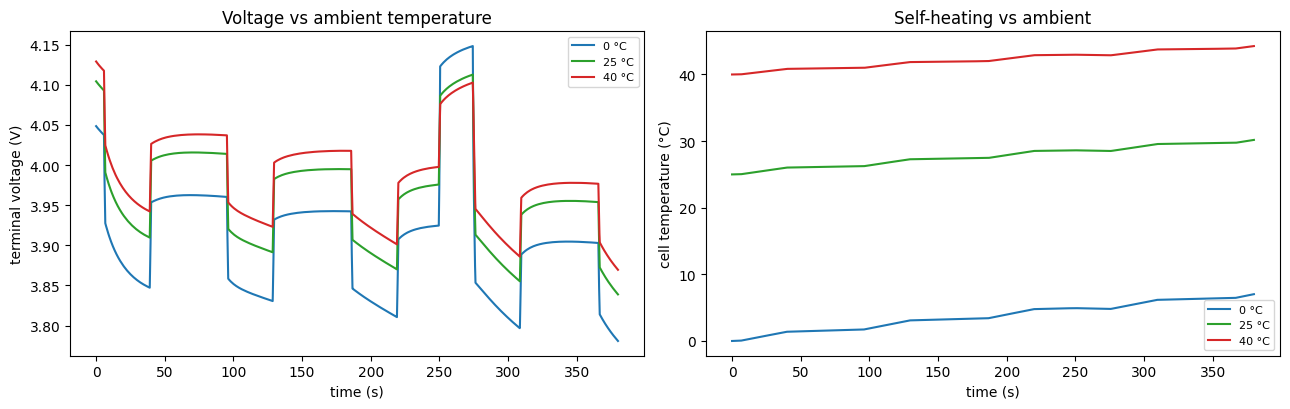

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for Tamb_C, col in [(0.0, "tab:blue"), (25.0, "tab:green"), (40.0, "tab:red")]:
    pT = pybamm.ParameterValues("Chen2020")
    pT["Ambient temperature [K]"] = 273.15 + Tamb_C
    pT["Initial temperature [K]"] = 273.15 + Tamb_C
    pT["Current function [A]"] = pybamm.Interpolant(tg, ebike_current(tg), pybamm.t)
    s = pybamm.Simulation(pybamm.lithium_ion.DFN(options={"thermal": "lumped"}), parameter_values=pT).solve([0, T_END])
    ax[0].plot(s["Time [s]"].entries, s["Terminal voltage [V]"].entries, color=col, label=f"{Tamb_C:.0f} °C")
    ax[1].plot(s["Time [s]"].entries, s["Volume-averaged cell temperature [K]"].entries - 273.15, color=col, label=f"{Tamb_C:.0f} °C")
ax[0].set(xlabel="time (s)", ylabel="terminal voltage (V)", title="Voltage vs ambient temperature"); ax[0].legend(fontsize=8)
ax[1].set(xlabel="time (s)", ylabel="cell temperature (°C)", title="Self-heating vs ambient"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

*Figure 4: the identical current profile at three ambient temperatures. Cold
cells sag lower (sluggish transport/kinetics) and would hit the cut-off sooner —
the physical origin of reduced winter range — while all self-heat by a few °C.*

## 9. Parameterisation & co-simulation — how the ladder connects to the vehicle

**Getting ECM parameters.** In practice you identify an ECM from **GITT/pulse
tests** (current pulses + relaxation isolate `R0` from the RC dynamics) on a real
cell, or — as we did in §4 — by **least-squares fitting the ECM to a DFN** you
trust. Either way the ECM's numbers become *traceable*.

**Coupling the battery to the vehicle sim.** Three patterns, cheapest first:
1. **Embedded reduced model (what Part 1 does).** The ECM lives *inside* the
   acausal circuit; current and voltage are solved simultaneously with the motor
   and vehicle. µs-cheap, fully coupled, real-time-capable.
2. **Offline one-way playback.** Run the vehicle sim → export the pack current
   $I(t)$ → drive a DFN offline for a detailed voltage/temperature/aging report.
   No feedback, but full fidelity for post-hoc analysis (this notebook's §4).
3. **Online co-stepping.** Advance the vehicle DAE and the DFN DAE in lockstep,
   exchanging (current ↔ voltage) each macro-step via operator splitting. Needed
   only when the battery's *fast* dynamics feed back into control within a step —
   rare for an e-bike, common for grid inverters.

**Data-driven ROMs.** You can also *learn* a reduced battery model from DFN (or
measured) data — DMDc, eDMDc, SINDyc — which is exactly what Jaxonomy's
`battery_part_4/5/6` tutorials do. That gives a fast block, like our ECM, but
fit by system-identification rather than circuit intuition.

## 10. Validation & failure modes

**Validation** (done above): SPMe reproduces the DFN to a few mV; the calibrated
ECM to ~15 mV; the aging curve is monotonic and physically paced; the
temperature trend has the right sign. Against a real cell you would additionally
validate the DFN parameters themselves against pulse and rate-test data.

**Failure modes — be specific:**
- **ECM extrapolation.** An ECM fit at 1C, 25 °C will mispredict a 4C cold pulse
  by tens–hundreds of mV; its RC branches have no transport physics to fall back
  on.
- **DFN parameter sensitivity.** DFN outputs are only as good as $D_s$, $i_0$,
  porosities, particle radii — often the least-known numbers in the model.
- **Aging model form.** SEI-only misses plating/cracking; the *mechanism* must
  match the regime (fast charge → plating; calendar → SEI).
- **Thermal coupling.** A lumped thermal model hides internal hot-spots (see the
  multi-node network in Part 1 / `ebike_thermal_rom.py`).

## 11. Exercises

1. **(code)** Re-fit the ECM to the DFN at a **3C** peak current instead of ~1C.
   How much does the ECM RMSE degrade, and which parameter moves most?
2. **(code)** Add the electrolyte-concentration *gradient magnitude*
   $\max_x c_e - \min_x c_e$ as a time series. When is it largest, and how does it
   correlate with the terminal-voltage sag?
3. **(concept)** The e-bike sits in the "ECM ok" regime. Name a realistic e-bike
   scenario that would push it out, and say which fidelity you'd switch to and why.
4. **(concept)** Sketch the data flow for **online co-stepping** the DFN with the
   Part-1 vehicle DAE. What is exchanged each step, and what could make the
   coupling unstable?
5. **(open-ended)** Fit a *data-driven* ROM (à la `battery_part_4` DMDc) to the
   DFN §4 data and compare it to the 2-RC ECM on accuracy, speed, and
   extrapolation to an unseen current profile.

## Key takeaways

- Battery models form a **fidelity ladder** — ECM (0-D) ↔ SPMe ↔ DFN (P2D) —
  trading spatial physics for speed.
- The DFN resolves **internal fields** (electrolyte + particle concentration)
  that drive fast-charge limits, temperature dependence, and aging; the ECM has
  no representation of them.
- You **earn** the cheap ECM by fitting/reducing it from the DFN (or GITT data),
  making its parameters defensible — then run it inside the vehicle model.
- Choose fidelity by the **question**: real-time vehicle/BMS → ECM; transient,
  thermal, aging, or design → DFN/SPMe.

**Next:** [Part 4](ebike_part4_mujoco_multibody.ipynb) — 3-D multibody dynamics
and co-simulation with MuJoCo.

## References
- M. Doyle, T. F. Fuller, J. Newman, *J. Electrochem. Soc.* **140**(6), 1993 (the DFN/P2D model).
- C.-H. Chen et al., *J. Electrochem. Soc.* **167**, 2020 (the "Chen2020" parameter set).
- V. Sulzer et al., *PyBaMM*, *J. Open Res. Software* **9**, 2021.